# Entrainement — Classification Bois / Cuivre

**Projet** : Gallica Images — Illustrations des *Metamorphoses* d'Ovide
**Corpus**  : illustrations segmentees, `data/editions_ovide/datasets/{train,val,test}/{bois,cuivre}/`

Deux strategies sont regroupees
ici derriere un seul parametre `STRATEGIE` :

| Strategie | Utilisee pour | Description |
|---|---|---|
| `"simple"` | v1, v2 | Reseau entierement degele des le depart, un seul appel a l'entrainement, `N_EPOCHS` epoques |
| `"deux_etapes"` | v3 | Etape 1 : couche finale seule (reseau gele). Etape 2 : reseau complet degele, lr plus faible |

Les deux strategies partagent : le chargement du dataset, les class weights,
la fonction d'entrainement avec early stopping, l'evaluation et la sauvegarde
des resultats (matrice de confusion, courbes, historique JSON).

Pour entrainer une nouvelle version : changer `VERSION` et `STRATEGIE` dans la
cellule de configuration ci-dessous, relancer tout le notebook.


---

## 1. Configuration

**Seule section a modifier** pour entrainer une nouvelle version.

In [ ]:
# ── Parametres — a modifier pour chaque version ─────────────
VERSION       = "v4.1.1"      # ex: v1, v2, v3.0.0, v4.0.0, v4.1.0, v4.1.1
STRATEGIE     = "deux_etapes" # "simple" (v1/v2) ou "deux_etapes" (v3, v4)
SEED          = 42            # fixe, identique a v4.0.0 pour un vrai A/B controle
DEGEL_ETAPE2  = "layer4"       # "complet" (v4.0.0/v4.1.0) ou "layer4" (v4.1.1 — degel partiel)

# -- strategie "simple" (v1/v2) --
N_EPOCHS_SIMPLE = 20
BATCH_SIZE      = 16
LR_SIMPLE       = 1e-4
STEP_LR         = 5
GAMMA_LR        = 0.5

# -- strategie "deux_etapes" (v3, v4) --
N_EPOCHS_ETAPE1   = 10   # couche finale seule
N_EPOCHS_ETAPE2   = 30   # reseau complet (ou layer4+fc si DEGEL_ETAPE2="layer4")
LR_ETAPE1         = 1e-3
LR_ETAPE2         = 1e-4  # meme valeur que v4.0.0 — seul DEGEL_ETAPE2 change ici
WEIGHT_DECAY_ETAPE2 = 0.0  # meme valeur que v4.0.0 — seul DEGEL_ETAPE2 change ici
PATIENCE_ETAPE1   = 5
PATIENCE_ETAPE2   = 7
# ────────────────────────────────────────────────────────────

import os, sys, json, random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, "..")
from gallica_utils import TRANSFORM_TRAIN, TRANSFORM_VAL, DEVICE

# Seed — rend les runs reproductibles pour comparer les variantes entre elles
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

RACINE          = os.path.abspath("../..")
DOSSIER_DATASET = os.path.join(RACINE, "data", "editions_ovide", "datasets")
DOSSIER_MODELES = os.path.join(RACINE, "modeles", "bois_cuivre")
DOSSIER_EVAL    = os.path.join(RACINE, "resultats", "evaluation_modeles", "bois_cuivre")

NOM_MODELE = f"resnet50_bois_cuivre_{VERSION}.pth" if STRATEGIE == "deux_etapes" else f"resnet50_{VERSION}.pth"
CHEMIN_PTH = os.path.join(DOSSIER_MODELES, NOM_MODELE)

os.makedirs(DOSSIER_MODELES, exist_ok=True)
os.makedirs(DOSSIER_EVAL,    exist_ok=True)

device = DEVICE
print(f"Device       : {device}")
print(f"Version      : {VERSION}")
print(f"Strategie    : {STRATEGIE}")
print(f"Seed         : {SEED}")
print(f"Degel etape2 : {DEGEL_ETAPE2}")
print(f"Sortie       : {CHEMIN_PTH}")

## 2. Chargement du dataset et sampler équilibré

`WeightedRandomSampler` tire les images de train avec une probabilité
inversement proportionnelle à la taille de leur classe : à chaque epoch,
bois et cuivre sont vus un nombre de fois équivalent, sans dupliquer de
fichiers ni retirer de données cuivre. Combiné à `TRANSFORM_TRAIN` (flip,
rotation, jitter), chaque tirage du bois est transformé différemment —
ce n'est donc pas une répétition strictement identique. Ne s'applique
qu'au train — val et test restent inchangés (shuffle simple).

In [9]:
dataset_train = datasets.ImageFolder(os.path.join(DOSSIER_DATASET, "train"), TRANSFORM_TRAIN)
dataset_val   = datasets.ImageFolder(os.path.join(DOSSIER_DATASET, "val"),   TRANSFORM_VAL)
dataset_test  = datasets.ImageFolder(os.path.join(DOSSIER_DATASET, "test"),  TRANSFORM_VAL)

# Sampler équilibré — poids inversement proportionnel à la taille de la classe
counts_train        = np.bincount(dataset_train.targets)
poids_par_classe     = 1.0 / counts_train
poids_par_echantillon = [poids_par_classe[t] for t in dataset_train.targets]
sampler_train = WeightedRandomSampler(
    poids_par_echantillon, num_samples=len(dataset_train), replacement=True
)

batch_size   = BATCH_SIZE if STRATEGIE == "simple" else 32
loader_train = DataLoader(dataset_train, batch_size=batch_size, sampler=sampler_train, num_workers=0)
loader_val   = DataLoader(dataset_val,   batch_size=batch_size, shuffle=False, num_workers=0)
loader_test  = DataLoader(dataset_test,  batch_size=batch_size, shuffle=False, num_workers=0)

CLASSES = dataset_train.classes
print(f"Classes : {CLASSES}")
print(f"Train   : {len(dataset_train)} | Val : {len(dataset_val)} | Test : {len(dataset_test)}")
for cls, n in zip(CLASSES, counts_train):
    print(f"  {cls:10s} : {n} images en train (avant sampler — vues à fréquence égale grâce au sampler)")

Classes : ['bois', 'cuivre']
Train   : 1169 | Val : 227 | Test : 233
  bois       : 345 images en train (avant sampler — vues à fréquence égale grâce au sampler)
  cuivre     : 824 images en train (avant sampler — vues à fréquence égale grâce au sampler)


## 3. Modele et poids de classe (information)

Affichés pour référence — **non utilisés dans la loss** : le sampler équilibré
(section 2) compense déjà le déséquilibre en présentant bois et cuivre à
fréquence égale à chaque epoch. Appliquer aussi les poids dans la loss
double-compenserait (le modèle serait alors biaisé vers le bois).

In [10]:
counts = np.bincount(dataset_train.targets)
total  = len(dataset_train)
class_weights_info = torch.tensor(
    [total / (len(CLASSES) * c) for c in counts], dtype=torch.float
)

print("Poids de classe (information seule, non appliqués — voir sampler section 2) :")
for cls, n, w in zip(CLASSES, counts, class_weights_info):
    print(f"  {cls:10s} : {n:>5} exemples -> weight {w:.4f}")

modele = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
modele.fc = nn.Linear(modele.fc.in_features, len(CLASSES))
modele    = modele.to(device)

if STRATEGIE == "simple":
    # reseau entierement degele des le depart
    for p in modele.parameters():
        p.requires_grad = True
else:
    # etape 1 : reseau gele, seule la couche finale est entrainable
    for p in modele.parameters():
        p.requires_grad = False
    for p in modele.fc.parameters():
        p.requires_grad = True

print(f"\n✓ ResNet50 charge — {len(CLASSES)} classes — strategie {STRATEGIE}")

Poids de classe (information seule, non appliqués — voir sampler section 2) :
  bois       :   345 exemples -> weight 1.6942
  cuivre     :   824 exemples -> weight 0.7093

✓ ResNet50 charge — 2 classes — strategie deux_etapes


## 4. Fonctions d'entrainement

Communes aux deux strategies — utilisees une fois (`simple`) ou deux fois (`deux_etapes`).

In [11]:
def train_epoch(modele, loader, criterion, optimizer):
    modele.train()
    total_loss = total_correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = modele(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item() * images.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total         += images.size(0)
    return total_loss / total, total_correct / total


def eval_epoch(modele, loader, criterion):
    modele.eval()
    total_loss = total_correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = modele(images)
            loss           = criterion(outputs, labels)
            total_loss    += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total         += images.size(0)
    return total_loss / total, total_correct / total


def entrainer(modele, loader_train, loader_val, criterion, optimizer,
              n_epochs, patience, chemin_pth, scheduler=None,
              meilleur_val_loss=float("inf")):
    """
    meilleur_val_loss : val_loss de reference a battre pour sauvegarder un
    nouveau meilleur modele. A passer explicitement d'un appel a l'autre
    (ex: etape 1 -> etape 2) pour que le meilleur epoch across les deux
    etapes soit vraiment conserve, plutot que reinitialise a chaque appel.
    """
    historique = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    patience_compteur = 0
    meilleur_epoch    = 0

    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc = train_epoch(modele, loader_train, criterion, optimizer)
        val_loss,   val_acc   = eval_epoch(modele,  loader_val,   criterion)

        historique["train_loss"].append(train_loss)
        historique["train_acc"] .append(train_acc)
        historique["val_loss"]  .append(val_loss)
        historique["val_acc"]   .append(val_acc)

        print(f"  Epoch {epoch:>3}/{n_epochs} "
              f"| train loss {train_loss:.4f} acc {train_acc:.4f} "
              f"| val loss {val_loss:.4f} acc {val_acc:.4f}", end="")

        if val_loss < meilleur_val_loss:
            meilleur_val_loss = val_loss
            meilleur_epoch    = epoch
            patience_compteur = 0
            torch.save(modele.state_dict(), chemin_pth)
            print(" ← meilleur")
        else:
            patience_compteur += 1
            print(f" (patience {patience_compteur}/{patience})")
            if patience_compteur >= patience:
                print(f"\n  Early stopping — meilleur epoch : {meilleur_epoch}")
                break

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

    return historique, meilleur_epoch, meilleur_val_loss

print("✓ Fonctions d'entrainement definies")

✓ Fonctions d'entrainement definies


## 5. Entrainement

In [12]:
criterion = nn.CrossEntropyLoss()  # pas de poids — sampler deja equilibre (section 2)

if STRATEGIE == "simple":
    optimizer = optim.Adam(modele.parameters(), lr=LR_SIMPLE)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_LR, gamma=GAMMA_LR)

    print("Entrainement — reseau complet\n")
    hist_total, meilleur_epoch, _ = entrainer(
        modele, loader_train, loader_val, criterion, optimizer,
        n_epochs=N_EPOCHS_SIMPLE, patience=N_EPOCHS_SIMPLE,  # pas d'early stopping en mode simple
        chemin_pth=CHEMIN_PTH, scheduler=scheduler
    )

else:
    optimizer1 = optim.Adam(modele.fc.parameters(), lr=LR_ETAPE1)
    print("Etape 1 — couche finale uniquement\n")
    hist1, best1, meilleur_val_loss = entrainer(
        modele, loader_train, loader_val, criterion, optimizer1,
        n_epochs=N_EPOCHS_ETAPE1, patience=PATIENCE_ETAPE1,
        chemin_pth=CHEMIN_PTH
    )
    print(f"\n✓ Etape 1 terminee — meilleur epoch : {best1} (val_loss={meilleur_val_loss:.4f})")

    # Repartir du meilleur modele de l'etape 1 (pas forcement le dernier epoch)
    modele.load_state_dict(torch.load(CHEMIN_PTH, map_location=device))

    if DEGEL_ETAPE2 == "complet":
        # degel total du reseau (v4.0.0, v4.1.0)
        for p in modele.parameters():
            p.requires_grad = True
    else:
        # degel partiel (v4.1.1) — seul le dernier bloc ResNet (layer4) + fc
        # sont entraines, le reste (conv1, layer1-3) reste gele. Moins de
        # capacite libre que le degel complet, pour un dataset aussi petit
        # (1169 images train) — cense reduire l'instabilite de val_loss
        # observee en v4.0.0/v4.1.0 (dégel complet, tres volatil).
        for p in modele.parameters():
            p.requires_grad = False
        for p in modele.layer4.parameters():
            p.requires_grad = True
        for p in modele.fc.parameters():
            p.requires_grad = True

    parametres_entrainables = [p for p in modele.parameters() if p.requires_grad]
    nb_total    = sum(p.numel() for p in modele.parameters())
    nb_entraine = sum(p.numel() for p in parametres_entrainables)
    print(f"Degel etape 2 ({DEGEL_ETAPE2}) : {nb_entraine:,} / {nb_total:,} parametres entrainables "
          f"({nb_entraine/nb_total:.1%})")

    # weight_decay (L2) — regularise, absent en v4.0.0/v4.1.1, present en v4.1.0
    optimizer2 = optim.Adam(parametres_entrainables, lr=LR_ETAPE2, weight_decay=WEIGHT_DECAY_ETAPE2)
    scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode="min", patience=3, factor=0.5)

    print("\nEtape 2 — fine-tuning\n")
    # meilleur_val_loss de l'etape 1 transmis ici : l'etape 2 ne remplacera
    # le modele sauvegarde que si elle fait reellement mieux que l'etape 1,
    # au lieu de reinitialiser la reference a l'infini et ecraser un meilleur
    # resultat precedent des le premier epoch de l'etape 2.
    hist2, best2, meilleur_val_loss = entrainer(
        modele, loader_train, loader_val, criterion, optimizer2,
        n_epochs=N_EPOCHS_ETAPE2, patience=PATIENCE_ETAPE2,
        chemin_pth=CHEMIN_PTH, scheduler=scheduler2,
        meilleur_val_loss=meilleur_val_loss
    )
    if best2 == 0:
        print(f"\n✓ Etape 2 terminee — aucun epoch n'a battu l'etape 1 "
              f"(meilleur modele conserve : etape 1, epoch {best1}, val_loss={meilleur_val_loss:.4f})")
    else:
        print(f"\n✓ Etape 2 terminee — meilleur epoch : {best2} (val_loss={meilleur_val_loss:.4f})")

    hist_total = {k: hist1[k] + hist2[k] for k in hist1}
    meilleur_epoch = best1 if best2 == 0 else len(hist1["train_loss"]) + best2

Etape 1 — couche finale uniquement

  Epoch   1/10 | train loss 0.2744 acc 0.9170 | val loss 0.2881 acc 0.8238 ← meilleur
  Epoch   2/10 | train loss 0.1032 acc 0.9760 | val loss 0.3395 acc 0.8106 (patience 1/5)
  Epoch   3/10 | train loss 0.0907 acc 0.9769 | val loss 0.3007 acc 0.8414 (patience 2/5)
  Epoch   4/10 | train loss 0.0702 acc 0.9846 | val loss 0.2617 acc 0.8546 ← meilleur
  Epoch   5/10 | train loss 0.0684 acc 0.9846 | val loss 0.3505 acc 0.8238 (patience 1/5)
  Epoch   6/10 | train loss 0.0936 acc 0.9624 | val loss 0.2234 acc 0.8767 ← meilleur
  Epoch   7/10 | train loss 0.0573 acc 0.9846 | val loss 0.3066 acc 0.8458 (patience 1/5)
  Epoch   8/10 | train loss 0.0446 acc 0.9897 | val loss 0.3790 acc 0.8194 (patience 2/5)
  Epoch   9/10 | train loss 0.0543 acc 0.9812 | val loss 0.1976 acc 0.9119 ← meilleur
  Epoch  10/10 | train loss 0.0437 acc 0.9872 | val loss 0.2568 acc 0.8678 (patience 1/5)

✓ Etape 1 terminee — meilleur epoch : 9 (val_loss=0.1976)
Degel etape 2 (layer4

## 6. Courbes loss et accuracy

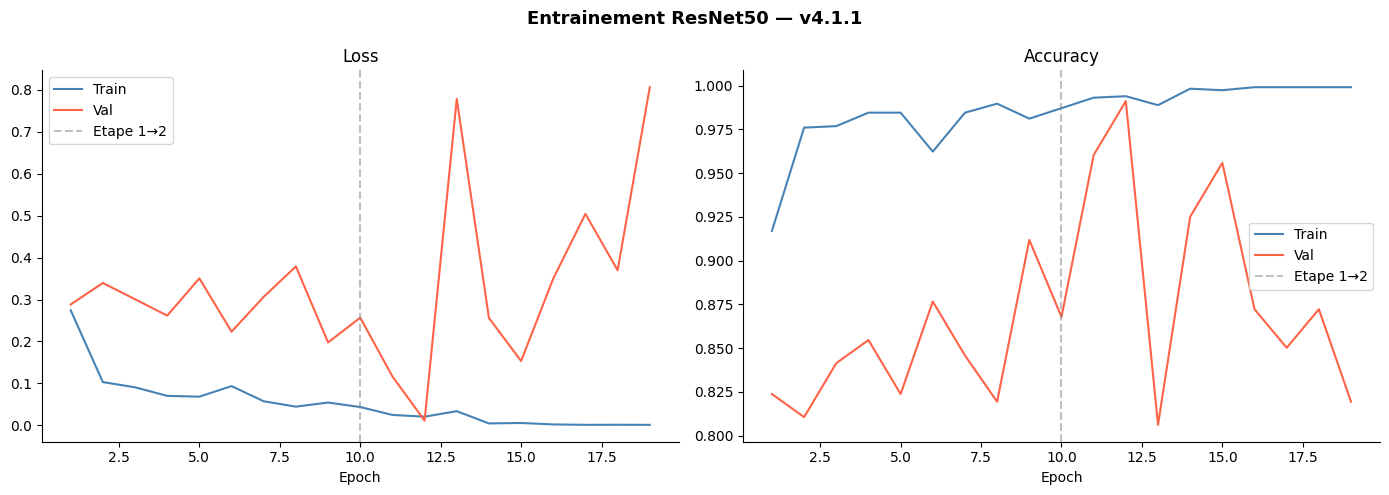

✓ Courbes sauvegardees


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Entrainement ResNet50 — {VERSION}", fontsize=13, fontweight="bold")

epochs = range(1, len(hist_total["train_loss"]) + 1)

axes[0].plot(epochs, hist_total["train_loss"], label="Train", color="steelblue")
axes[0].plot(epochs, hist_total["val_loss"],   label="Val",   color="tomato")
if STRATEGIE == "deux_etapes":
    axes[0].axvline(x=len(hist1["train_loss"]), color="gray", linestyle="--", alpha=0.5, label="Etape 1→2")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(epochs, hist_total["train_acc"], label="Train", color="steelblue")
axes[1].plot(epochs, hist_total["val_acc"],   label="Val",   color="tomato")
if STRATEGIE == "deux_etapes":
    axes[1].axvline(x=len(hist1["train_loss"]), color="gray", linestyle="--", alpha=0.5, label="Etape 1→2")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_EVAL, f"courbes_{VERSION}.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✓ Courbes sauvegardees")

## 7. Evaluation sur le test set

Rapport de classification :

              precision    recall  f1-score   support

        bois     0.9524    0.9836    0.9677        61
      cuivre     0.9941    0.9826    0.9883       172

    accuracy                         0.9828       233
   macro avg     0.9732    0.9831    0.9780       233
weighted avg     0.9832    0.9828    0.9829       233



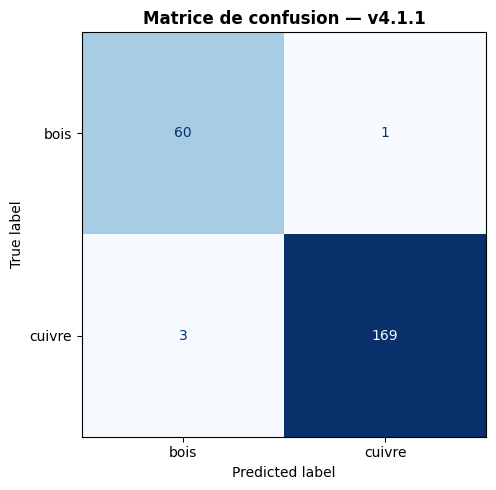

✓ Matrice sauvegardee
✓ Historique sauvegarde


In [14]:
modele.load_state_dict(torch.load(CHEMIN_PTH, map_location=device))
modele.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in loader_test:
        images = images.to(device)
        preds  = modele(images).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("Rapport de classification :\n")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

cm  = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matrice de confusion — {VERSION}", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_EVAL, f"matrice_confusion_{VERSION}.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✓ Matrice sauvegardee")

with open(os.path.join(DOSSIER_EVAL, f"historique_{VERSION}.json"), "w") as f:
    json.dump(hist_total, f, indent=2)
print("✓ Historique sauvegarde")